In [37]:
import torch 
import torch.nn as nn 
import torch.optim as optim



In [38]:
import urllib.request
import zipfile
import os

URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
ZIP_PATH = "UCI_HAR_Dataset.zip"
EXTRACT_DIR = "data"

if not os.path.exists(ZIP_PATH):
    print("Downloading UCI HAR dataset...")
    urllib.request.urlretrieve(URL, ZIP_PATH)


if not os.path.exists(os.path.join(EXTRACT_DIR, "UCI HAR Dataset")):
    print("Extracting dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

print("Done.")


Done.


In [39]:
import numpy as np
import os

BASE = "data/UCI HAR Dataset"

def load_har(split="train"):
    base = os.path.join(BASE, split, "Inertial Signals")
    signals = [
        "body_acc_x", "body_acc_y", "body_acc_z",
        "body_gyro_x", "body_gyro_y", "body_gyro_z",
        "total_acc_x", "total_acc_y", "total_acc_z",
    ]

    X = []
    for s in signals:
        X.append(
            np.loadtxt(os.path.join(base, f"{s}_{split}.txt"))
        )

    X = np.stack(X, axis=-1)              # (N, 128, 9)
    y = np.loadtxt(
        os.path.join(BASE, split, f"y_{split}.txt")
    ) - 1                                 # Labels 0..5

    return X.astype("float32"), y.astype("int32")


In [40]:
X_train, y_train = load_har("train")
X_test,  y_test  = load_har("test")

print(X_train.shape)  # (7352, 128, 9)
print(y_train.shape)  # (7352,)

mean = X_train.mean(axis=(0, 1), keepdims=True)
std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-6

X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std


(7352, 128, 9)
(7352,)


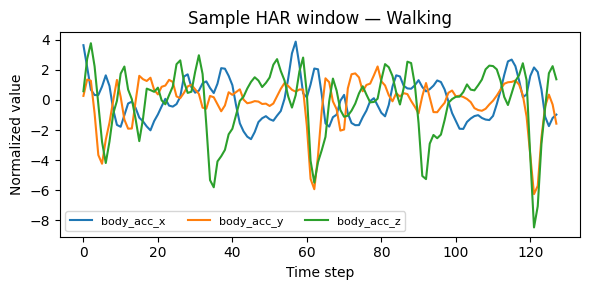

In [41]:
import matplotlib.pyplot as plt

class_names = [
    'Walking',
    'Walking Upstairs',
    'Walking Downstairs',
    'Sitting',
    'Standing',
    'Laying',
]

idx = 5001  # change to view a different sample
t = range(X_train.shape[1])
activity = class_names[int(y_train[idx])]

plt.figure(figsize=(6, 3))
plt.plot(t, X_train[idx, :, 0], label='body_acc_x')
plt.plot(t, X_train[idx, :, 1], label='body_acc_y')
plt.plot(t, X_train[idx, :, 2], label='body_acc_z')
plt.xlabel('Time step')
plt.ylabel('Normalized value')
plt.title(f'Sample HAR window — {activity}')
plt.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()


In [42]:
from torch.utils.data import TensorDataset, DataLoader, random_split

BATCH = 64
device = "mps" # mac -> mps, windows -> cpu 

train_ds_full = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test).long())

val_frac = 0.15
val_size = int(len(train_ds_full) * val_frac)
train_size = len(train_ds_full) - val_size
generator = torch.Generator().manual_seed(1)
train_ds, val_ds = random_split(train_ds_full, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False) # für Hyperparameter-Tuning 
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False)


In [43]:
class hRNN(nn.Module):
    def __init__(self, num_classes = 6, input_size = 9):
        super().__init__()
        # Two stage procedure 
        # Stadium 1 Feature extraction 
        self.rnn = nn.GRU(input_size, hidden_size=32, batch_first=True ) # if batch_first= False -> (128, BATCH, 9)
                                                                        # if batch_first= True -> (BATCH, 128, 9)                                                                         
        # Stadium 2 Klassifikation MLP-Head 
        self.fc1 = nn.Linear(in_features=32, out_features=128)
        self.bn = nn.BatchNorm1d(128)
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)
    
    def forward(self,x):
        # Stadium 1
        #  
        h, _ = self.rnn(x)  
        out = h[:,-1,:] # flatten 
        # Stadium 2
        #   
        out = torch.relu(self.fc1(out))  
        out = self.bn(out)
        out = self.drop(out)
        return self.fc2(out) # CrossEntropyLoss funktioniert in Pytorch mit logits (keine Aktivierung)

model = hRNN().to(device)

In [44]:
loss = nn.CrossEntropyLoss() # weil Multi-Klassen-Problem 
optimizer = optim.Adam(model.parameters(), lr = 1e-3)

epochs = 50 
patience = 5 # 3-5-7 patience = Anzahl der konsekutiven Epochen ohne Verbesserung 
# üblicherweise val_loss 
# manchmal test_loss, aber auch alle möglichen Metriken 
best_val_loss = float('inf') 
patience_left = patience 
best_state = None

for epoch in range(1, epochs+1):
    model.train()

    train_loss = .0
    train_correct = 0
    train_count = 0 

    for xb,yb in train_loader:
        xb = xb.to(device) 
        yb = yb.to(device)
        
        # Training 
        optimizer.zero_grad()
        logits = model(xb) # Vorhersage
        loss_out = loss(logits, yb) # Vorhersage - Realität = Loss 
        loss_out.backward()
        optimizer.step()

        batch_size = xb.size(0)
        train_loss += loss_out.item() * batch_size
        train_correct += (logits.argmax(dim=1)==yb).sum().item() 
        train_count += batch_size
    
    train_loss /= train_count # mean CrossEntropy 
    train_acc = train_correct / train_count 

    model.eval() # Test data
    val_loss = 0.0
    val_correct = 0
    val_count = 0

    with torch.no_grad():
        for xb,yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss_out = loss(logits,yb)

            batch_size = xb.size(0)
            val_loss += loss_out.item() * batch_size
            val_correct += (logits.argmax(dim=1) == yb).sum().item() 
            val_count += batch_size
    
    val_loss /= val_count
    val_acc  = val_correct/val_count 

    print(
        f"Epoch {epoch:02d} | train_loss={train_loss:.4f} acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} acc={val_acc:.4f}"
    )

    if val_loss < best_val_loss - 1e-3: 
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_left = patience
    else:
        patience_left -= 1
        if patience_left == 0:
            print ("Abbrechen")
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01 | train_loss=1.0282 acc=0.6061 | val_loss=0.7739 acc=0.6963
Epoch 02 | train_loss=0.6627 acc=0.7365 | val_loss=0.6681 acc=0.7296
Epoch 03 | train_loss=0.5210 acc=0.7984 | val_loss=0.5629 acc=0.7805
Epoch 04 | train_loss=0.4183 acc=0.8480 | val_loss=0.4833 acc=0.8252
Epoch 05 | train_loss=0.3172 acc=0.8890 | val_loss=0.4010 acc=0.8704
Epoch 06 | train_loss=0.2370 acc=0.9133 | val_loss=0.3249 acc=0.8873
Epoch 07 | train_loss=0.1789 acc=0.9336 | val_loss=0.3000 acc=0.8945
Epoch 08 | train_loss=0.1569 acc=0.9387 | val_loss=0.3092 acc=0.8958
Epoch 09 | train_loss=0.1421 acc=0.9456 | val_loss=0.2949 acc=0.9043
Epoch 10 | train_loss=0.1386 acc=0.9470 | val_loss=0.2513 acc=0.9067
Epoch 11 | train_loss=0.1274 acc=0.9475 | val_loss=0.2441 acc=0.9141
Epoch 12 | train_loss=0.1213 acc=0.9502 | val_loss=0.2431 acc=0.9074
Epoch 13 | train_loss=0.1239 acc=0.9478 | val_loss=0.2895 acc=0.9006
Epoch 14 | train_loss=0.1194 acc=0.9515 | val_loss=0.2588 acc=0.9114
Epoch 15 | train_loss=0.1174 acc=0

In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix

model.eval()
all_logits = []

with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        all_logits.append(logits.cpu().numpy())

logits = np.concatenate(all_logits, axis=0)
y_pred = np.argmax(logits, axis=1)

cm = confusion_matrix(y_test, y_pred)
cm


array([[478,   6,  11,   1,   0,   0],
       [ 11, 442,  18,   0,   0,   0],
       [  2,  14, 404,   0,   0,   0],
       [  0,   4,   0, 355, 126,   6],
       [  0,   2,   0,  52, 478,   0],
       [  0,   0,   0,   0,   0, 537]])

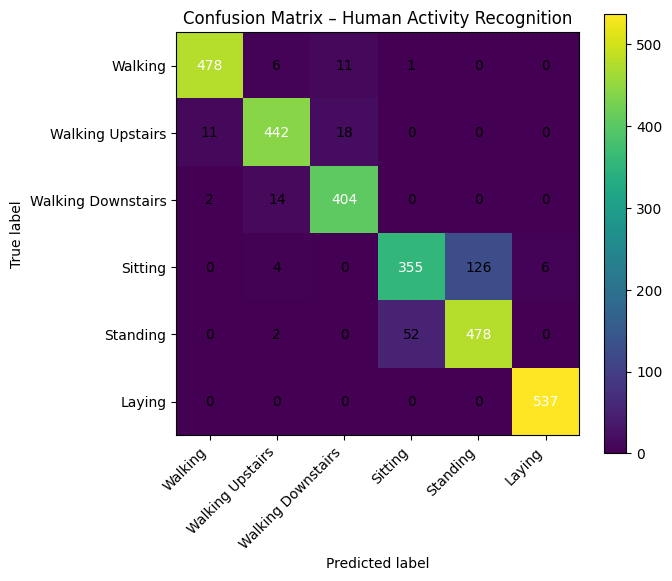

In [46]:
import matplotlib.pyplot as plt

class_names = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying",
]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix – Human Activity Recognition")

# Werte einzeichnen
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()